In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# Barnet boundary overlaps

**Author**: Sian Teesdale

**Date created**: April 2026

**Dataset Scope**: `conservation-area`, `article-4-direction-area`, `listed-building-outline`

**Purpose**: Ad-hoc investigation into geometries crossing LPA boundaries around Barnet. Three questions:
1. Are Trent Park (Enfield, entity `44010289`) and the neighbouring Monken Hadley (Barnet, entity `44002424`) conservation areas genuinely separate, or duplicates of the same area split across two LPAs' submissions?
2. Does listed-building-outline entity `42115855`, submitted by Camden, actually sit within Barnet's boundary?
3. More generally: across Barnet's six neighbouring LPAs (Brent, Camden, Enfield, Haringey, Harrow, Hertsmere) and three datasets (conservation-area, article-4-direction-area, listed-building-outline), which submitted geometries overlap into Barnet's boundary at all?

Reads live from `files.planning.data.gov.uk` throughout — no local data dependencies. (The original working session also exported several `.gpkg`/`.csv` files for exploring the results in QGIS; those aren't reproduced here since they're regenerable from this notebook or were QGIS-only exports not used by any code below.)

In [ ]:
# LPA boundary
boundary = gpd.read_file("https://files.planning.data.gov.uk/dataset/local-planning-authority.geojson")

In [3]:
# Conservation areas
df = gpd.read_file("https://files.planning.data.gov.uk/dataset/conservation-area.geojson")

In [ ]:
# Barnet has an organisation-entity of 48
df_barnet = df.loc[df['organisation-entity'] == '48']

# Save to file so I can explore better in QGIS
df_barnet.to_file("barnet_conservation_areas.gpkg", driver='GPKG')

In [6]:
len(df_barnet) # There are 16 conservation areas in Barnet

16

---

## Overlapping CA with Trent Park and Monken Heath

Investigate the CA overlap between Trent Park (44010289) and neighbouring Monken Hadley (44002424). LPAs are Barnet and Enfield

In [7]:
overlap = df.loc[(df['entity']== '44010289') | (df['entity']== '44002424')]

In [8]:
overlap.head()

,dataset,end-date,entity,entry-date,name,organisation-entity,prefix,quality,reference,start-date,typology,legislation,notes,document-url,documentation-url,designation-date,geometry
1691,conservation-area,,44002424,2025-03-20,Monken Hadley,48,conservation-area,authoritative,CA01,2007-01-15,geography,None,None,https://open.barnet.gov.uk/download/2nx73/l7t,https://www.barnet.gov.uk/node/9019,1968-12-20,"POLYGON ((-0.19982 51.67015, -0.20011 51.67009..."
6609,conservation-area,,44010289,2024-08-15,TRENT PARK,126,conservation-area,authoritative,CA18,2015-02-01,geography,None,LBE,None,https://www.enfield.gov.uk/__data/assets/pdf_f...,1973-01-01,"POLYGON ((-0.14206 51.66755, -0.14314 51.6674,..."


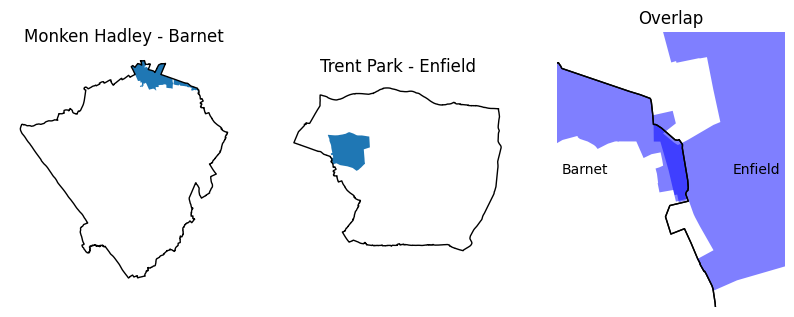

In [20]:
f, ax = plt.subplots(1,3, figsize=(10,10))

overlap.loc[overlap['entity'] == '44002424'].plot(ax=ax[0])
boundary.loc[(boundary['name'].str.contains("Barnet"))].plot(ax=ax[0], edgecolor='black', facecolor='none')

overlap.loc[overlap['entity'] == '44010289'].plot(ax=ax[1])
boundary.loc[(boundary['name'].str.contains("Enfield"))].plot(ax=ax[1], edgecolor='black', facecolor='none')

overlap.plot(ax=ax[2], color='blue', alpha=0.5)
boundary.loc[(boundary['name'].str.contains("Barnet")) | (boundary['name'].str.contains('Enfield'))].plot(ax=ax[2], edgecolor='black', facecolor='none')


ax[2].set_xlim(-0.158, -0.15)
ax[2].set_ylim(51.651, 51.657)

ax[0].set_title('Monken Hadley - Barnet')
ax[1].set_title('Trent Park - Enfield')
ax[2].set_title('Overlap')

ax[0].set_axis_off()
ax[1].set_axis_off()
ax[2].set_axis_off()

ax[2].annotate('Barnet', xy=(0.02, 0.5), xycoords='axes fraction', ha='left', va='center', fontsize=10)
ax[2].annotate('Enfield', xy=(0.98, 0.5), xycoords='axes fraction', ha='right', va='center', fontsize=10)

plt.show()

<Axes: >

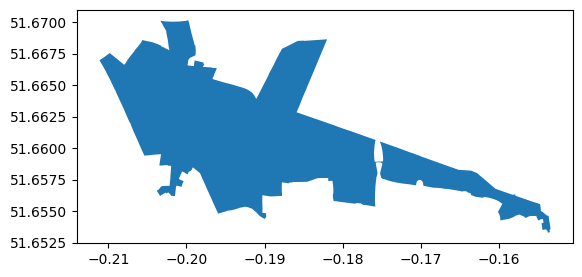

In [10]:
# Check if the individual entities match the document URL shapes
overlap.loc[overlap['entity'] == '44002424'].plot()

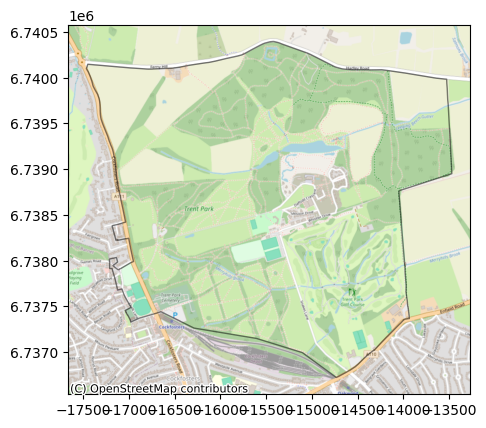

In [13]:
import contextily as ctx

ax = overlap.loc[overlap['entity'] == '44010289'].to_crs(epsg=3857).plot(alpha=0.5, edgecolor='black', facecolor='none')
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)


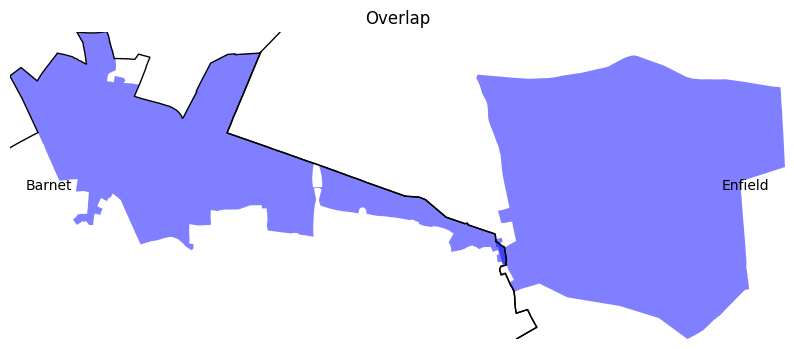

In [18]:
f, ax = plt.subplots(1, figsize=(10,10))

overlap.plot(ax=ax, color='blue', alpha=0.5)
boundary.loc[(boundary['name'].str.contains("Barnet")) | (boundary['name'].str.contains('Enfield'))].plot(ax=ax, edgecolor='black', facecolor='none')

#ax.set_xlim(-0.158, -0.15)
#ax.set_ylim(51.651, 51.657)

minx, miny, maxx, maxy = overlap.total_bounds
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)


ax.set_title('Overlap')

ax.set_axis_off()

ax.annotate('Barnet', xy=(0.02, 0.5), xycoords='axes fraction', ha='left', va='center', fontsize=10)
ax.annotate('Enfield', xy=(0.98, 0.5), xycoords='axes fraction', ha='right', va='center', fontsize=10)

#ctx.add_basemap(ax, crs=overlap.crs, source=ctx.providers.OpenStreetMap.Mapnik)

plt.show()


---
## Listed buildings outline

I've been asked to investigate entity 42115855 in LBO, and whether this is within Barnet's boundary

In [23]:
# Conservation areas
df_lbo = gpd.read_file("https://files.planning.data.gov.uk/dataset/listed-building-outline.geojson")

(51.560482, 51.56249)

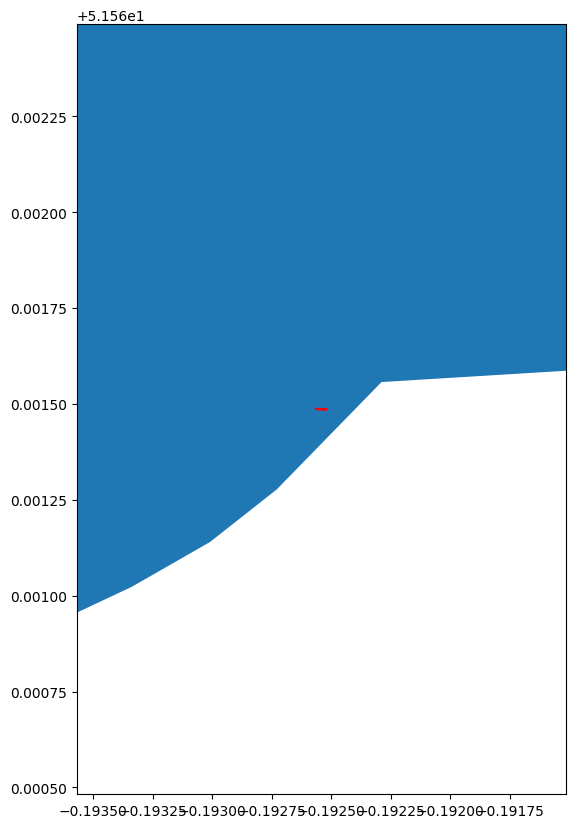

In [29]:
f, ax = plt.subplots(1, figsize=(10,10))

df_lbo.loc[df_lbo['entity'] == '42115855'].plot(ax=ax, facecolor='red', zorder=10)

boundary.loc[(boundary['name'].str.contains("Barnet"))].plot(ax=ax, zorder=1)

minx, miny, maxx, maxy = df_lbo.loc[df_lbo['entity'] == '42115855'].total_bounds
ax.set_xlim(minx-0.001, maxx+0.001)
ax.set_ylim(miny-0.001, maxy+0.001)


Yes, the LBO sits within Barnet LPA despite it being from Camden LPA.

---
## Any overlaps of other LPA geometries into Barnet's boundary?

- Datasets of interest: CAs, A4Ds, LBs
- Barnet's neighbouring LPAs: Brent, Camden, Harrow, Hertsmere, Enfield, Haringey


In [ ]:
neighbours = ['Brent', 'Camden', 'Enfield', 'Haringey', 'Harrow', 'Hertsmere']
datasets = ['conservation-area', 'article-4-direction', 'listed-building-outline']

neighbour_org_entities = {
    'Brent': '42',
    'Camden': '90',
    'Enfield': '126',
    'Haringey': '175',
    'Harrow': '174',
    'Hertsmere': '165'}

In [ ]:
# Read in A4D and LBO data
df_a4d = gpd.read_file("https://files.planning.data.gov.uk/dataset/article-4-direction-area.geojson")
df_lbo = gpd.read_file("https://files.planning.data.gov.uk/dataset/listed-building-outline.geojson")

In [ ]:
# Filter for our neighbouring LPAs
neighbouring_a4d = df_a4d.loc[df_a4d['organisation-entity'].isin([neighbour_org_entities[neighbour] for neighbour in neighbours])]
neighbouring_lbo = df_lbo.loc[df_lbo['organisation-entity'].isin([neighbour_org_entities[neighbour] for neighbour in neighbours])]

# Use the existing CA dataframe
neighbouring_ca = df.loc[df['organisation-entity'].isin([neighbour_org_entities[neighbour] for neighbour in neighbours])]

# Concat together
neighbouring_data = pd.concat([neighbouring_a4d, neighbouring_lbo, neighbouring_ca])[['dataset', 'entity', 'name', 'organisation-entity', 'geometry']]

In [86]:
len(neighbouring_data)

3168

In [ ]:
# Map the organisation names for ease
neighbouring_data['organisation_name'] = neighbouring_data['organisation-entity'].map({v: k for k, v in neighbour_org_entities.items()})

In [ ]:
# Record Barnet's boundary for overlay
barnet = boundary.loc[(boundary['name'].str.contains("Barnet"))]

In [64]:
# Find if neighbouring data overlaps with Barnet
overlap = gpd.overlay(neighbouring_data, barnet, how='intersection')

/Users/sianteesdale/miniconda/lib/python3.12/site-packages/geopandas/tools/overlay.py:358: UserWarning: `keep_geom_type=True` in overlay resulted in 348 dropped geometries of different geometry types than df1 has. Set `keep_geom_type=False` to retain all geometries
  result = _collection_extract(result, geom_type, keep_geom_type_warning)


In [ ]:
# What are the overlapping entities? There's a total of 17 of them
overlap[['dataset_1', 'entity_1', 'name_1', 'organisation_name']]

,dataset_1,entity_1,name_1,organisation_name
0,article-4-direction-area,7010002599,Hampstead Conservation Area (excl. Frognal Way...,Camden
1,article-4-direction-area,7010002613,Basements,Camden
2,article-4-direction-area,7010003994,Borough wide,Enfield
3,article-4-direction-area,7010007554,Hampstead Conservation Area (excl. Frognal Way...,Camden
4,article-4-direction-area,7010007555,Redington/Frognal Conservation Area Non-immedi...,Camden
5,article-4-direction-area,7010009611,Article 4 for HMOs,Brent
6,listed-building-outline,42115855,(West side) Cattle Trough at junction with Her...,Camden
7,listed-building-outline,42117067,(South East side) Kenwood West Lodge with flan...,Camden
8,listed-building-outline,42117134,(East side) Toll Gate House,Camden
9,conservation-area,44009615,Redington Frognal,Camden


In [ ]:
# Get full overlap extent from overlap
overlap_entities = overlap['entity_1']
overlap_entities = neighbouring_data.loc[neighbouring_data['entity'].isin(overlap_entities)]

In [ ]:
# Save all files to explore in QGIS further
overlap.to_file("barnet_overlap.gpkg", driver='GPKG')
overlap_entities.to_file("barnet_overlap_entities.gpkg", driver='GPKG')
barnet.to_file("barnet_boundary.gpkg", driver='GPKG')